# Fase 3 — Extensión: Datos Reales Alternativos
## Modelamiento del crecimiento de conexiones de Internet Fija en Chile (2000–2025)

**Fuente de datos:** Subsecretaría de Telecomunicaciones de Chile (SUBTEL) — *Serie histórica de conexiones totales de Internet fijo, Diciembre 2025.*

En esta fase aplicamos los modelos de Malthus y logístico a datos reales de crecimiento tecnológico. Se busca responder: **¿puede la dinámica de adopción de Internet en Chile ser capturada por modelos de crecimiento poblacional clásicos?**

---
### Estructura del notebook
1. Carga y exploración de los datos
2. Modelo de Malthus (crecimiento exponencial)
3. Modelo Logístico (crecimiento con capacidad de carga)
4. Comparación de modelos y error cuadrático medio
5. Discusión y limitaciones

---
## 1. Importación de librerías y carga de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# Configuración global de gráficos
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ---------------------------------------------------------------
# DATOS: Conexiones anuales de Internet Fijo en Chile (Dic de cada año)
# Fuente: SUBTEL — Serie 7.1 Conexiones Totales Fijas, Diciembre 2025
# ---------------------------------------------------------------

años = np.array([
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
    2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
    2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025
], dtype=float)

conexiones = np.array([
     585489,  698127,  757760,  836007,  805315,  906079,
    1087738, 1331919, 1439009, 1695034, 1819564, 2025042,
    2186173, 2309572, 2501356, 2729251, 2912133, 3068528,
    3256097, 3434767, 3802033, 4287491, 4460212, 4524579,
    4690891, 4796680
], dtype=float)

# Normalización temporal: t = 0 corresponde al año 2000
t = años - años[0]

print(f"Período: {int(años[0])} – {int(años[-1])}")
print(f"Número de observaciones anuales: {len(años)}")
print(f"Conexiones en 2000: {int(conexiones[0]):,}")
print(f"Conexiones en 2025: {int(conexiones[-1]):,}")
print(f"Crecimiento total: {conexiones[-1]/conexiones[0]:.2f}x")

Período: 2000 – 2025
Número de observaciones anuales: 26
Conexiones en 2000: 585,489
Conexiones en 2025: 4,796,680
Crecimiento total: 8.19x


---
## 2. Exploración visual de los datos

KeyboardInterrupt: 

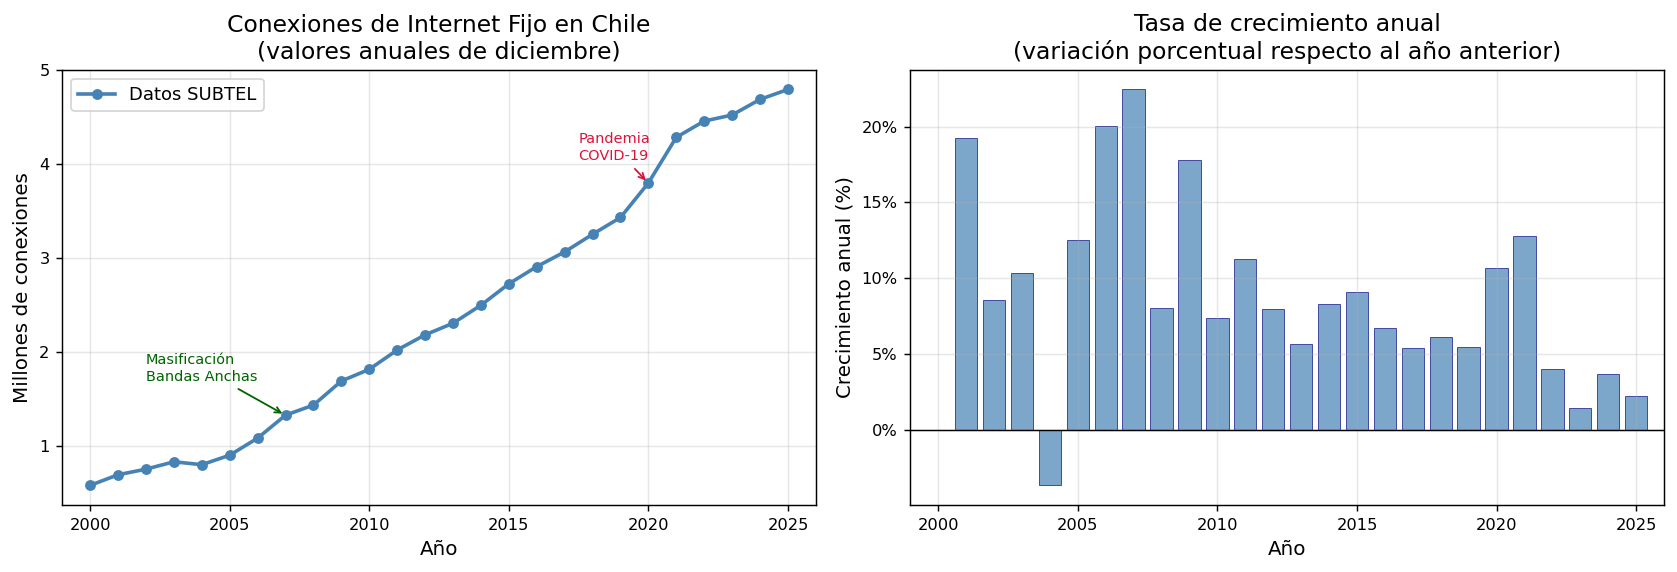

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Panel izquierdo: Serie original ---
ax = axes[0]
ax.plot(años, conexiones / 1e6, 'o-', color='steelblue', linewidth=2,
        markersize=5, label='Datos SUBTEL')
ax.set_title('Conexiones de Internet Fijo en Chile\n(valores anuales de diciembre)')
ax.set_xlabel('Año')
ax.set_ylabel('Millones de conexiones')
ax.set_xlim(1999, 2026)
ax.legend()

# Anotaciones de eventos relevantes
ax.annotate('Pandemia\nCOVID-19', xy=(2020, 3.80), xytext=(2017.5, 4.05),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            fontsize=8, color='crimson')
ax.annotate('Masificación\nBandas Anchas', xy=(2007, 1.33), xytext=(2002, 1.7),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=8, color='darkgreen')

# --- Panel derecho: crecimiento anual ---
ax2 = axes[1]
tasas = np.diff(conexiones) / conexiones[:-1] * 100
ax2.bar(años[1:], tasas, color='steelblue', alpha=0.7, edgecolor='navy', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Tasa de crecimiento anual\n(variación porcentual respecto al año anterior)')
ax2.set_xlabel('Año')
ax2.set_ylabel('Crecimiento anual (%)')
ax2.set_xlim(1999, 2026)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('internet_chile_exploracion.pdf', bbox_inches='tight')
plt.show()
print("\nObservación: La tasa de crecimiento decrece sostenidamente desde ~2007,")
print("lo que sugiere saturación progresiva del mercado — compatible con modelo logístico.")

---
## 3. Modelo de Malthus (crecimiento exponencial continuo)

El modelo de Malthus continuo establece que la población (o en este caso, el número de conexiones) crece a una tasa proporcional a su tamaño actual:

$$\frac{dX}{dt} = \alpha X \implies X(t) = X_0 \, e^{\alpha t}$$

donde $\alpha > 0$ es la tasa intrínseca de crecimiento y $X_0 = X(0)$ es el valor inicial.

El parámetro $\alpha$ se estima ajustando la curva $X(t) = X_0 e^{\alpha t}$ a los datos observados, minimizando el error cuadrático.

In [4]:
# ---------------------------------------------------------------
# Definición del modelo de Malthus continuo
# ---------------------------------------------------------------
def malthus(t, X0, alpha):
    """Modelo de crecimiento de Malthus: X(t) = X0 * exp(alpha * t)"""
    return X0 * np.exp(alpha * t)

# Ajuste de parámetros por mínimos cuadrados no lineales
p0_malthus = [conexiones[0], 0.08]   # valores iniciales razonables
params_malthus, cov_malthus = curve_fit(malthus, t, conexiones, p0=p0_malthus,
                                         maxfev=10000)
X0_m, alpha_m = params_malthus

print("=== MODELO DE MALTHUS ===")
print(f"  X₀ (valor inicial ajustado) = {X0_m:,.0f} conexiones")
print(f"  α  (tasa de crecimiento)    = {alpha_m:.5f} por año")
print(f"  Tiempo de duplicación       = {np.log(2)/alpha_m:.2f} años")

# Predicciones
t_fino = np.linspace(0, 30, 500)
años_fino = t_fino + 2000
pred_malthus = malthus(t_fino, X0_m, alpha_m)
pred_malthus_datos = malthus(t, X0_m, alpha_m)

# Error cuadrático medio (ECM)
ecm_malthus = np.mean((conexiones - pred_malthus_datos)**2)
rmse_malthus = np.sqrt(ecm_malthus)
print(f"\n  ECM  = {ecm_malthus:.3e}")
print(f"  RMSE = {rmse_malthus:,.0f} conexiones")
print(f"  RMSE relativo = {rmse_malthus/np.mean(conexiones)*100:.1f}% de la media")

=== MODELO DE MALTHUS ===
  X₀ (valor inicial ajustado) = 837,272 conexiones
  α  (tasa de crecimiento)    = 0.07379 por año
  Tiempo de duplicación       = 9.39 años

  ECM  = 4.334e+10
  RMSE = 208,174 conexiones
  RMSE relativo = 8.6% de la media


---
## 4. Modelo Logístico (crecimiento con capacidad de carga)

El modelo logístico continuo corrige la hipótesis de Malthus incorporando una **capacidad de carga** $L$ (número máximo de conexiones que el sistema puede sostener):

$$\frac{dX}{dt} = \rho \, X \left(1 - \frac{X}{L}\right)$$

cuya solución exacta es la **sigmoide logística**:

$$X(t) = \frac{L}{1 + \left(\dfrac{L - X_0}{X_0}\right) e^{-\rho t}}$$

- $\rho > 0$: tasa intrínseca de crecimiento
- $L > 0$: capacidad de carga (límite superior)
- $X_0 = X(0)$: condición inicial

In [5]:
# ---------------------------------------------------------------
# Definición del modelo logístico continuo
# ---------------------------------------------------------------
def logistico(t, rho, L, X0):
    """Solución exacta del modelo logístico continuo."""
    return L / (1 + ((L - X0) / X0) * np.exp(-rho * t))

# Valores iniciales: rho cercano al de Malthus, L mayor al máximo observado
p0_log = [0.15, 6e6, conexiones[0]]
bounds_log = ([0, conexiones[-1], 0], [2.0, 2e7, conexiones[0]*3])

params_log, cov_log = curve_fit(logistico, t, conexiones, p0=p0_log,
                                 bounds=bounds_log, maxfev=20000)
rho_l, L_l, X0_l = params_log

print("=== MODELO LOGÍSTICO ===")
print(f"  X₀ (valor inicial ajustado) = {X0_l:,.0f} conexiones")
print(f"  ρ  (tasa intrínseca)        = {rho_l:.5f} por año")
print(f"  L  (capacidad de carga)     = {L_l/1e6:.3f} millones de conexiones")
print(f"  Saturación actual (2025)    = {conexiones[-1]/L_l*100:.1f}% de L")

# Predicciones
pred_logistico = logistico(t_fino, rho_l, L_l, X0_l)
pred_logistico_datos = logistico(t, rho_l, L_l, X0_l)

# Error cuadrático medio
ecm_logistico = np.mean((conexiones - pred_logistico_datos)**2)
rmse_logistico = np.sqrt(ecm_logistico)
print(f"\n  ECM  = {ecm_logistico:.3e}")
print(f"  RMSE = {rmse_logistico:,.0f} conexiones")
print(f"  RMSE relativo = {rmse_logistico/np.mean(conexiones)*100:.1f}% de la media")

=== MODELO LOGÍSTICO ===
  X₀ (valor inicial ajustado) = 584,464 conexiones
  ρ  (tasa intrínseca)        = 0.12959 por año
  L  (capacidad de carga)     = 7.006 millones de conexiones
  Saturación actual (2025)    = 68.5% de L

  ECM  = 8.808e+09
  RMSE = 93,852 conexiones
  RMSE relativo = 3.9% de la media


---
## 5. Comparación visual: Malthus vs Logístico vs Datos reales

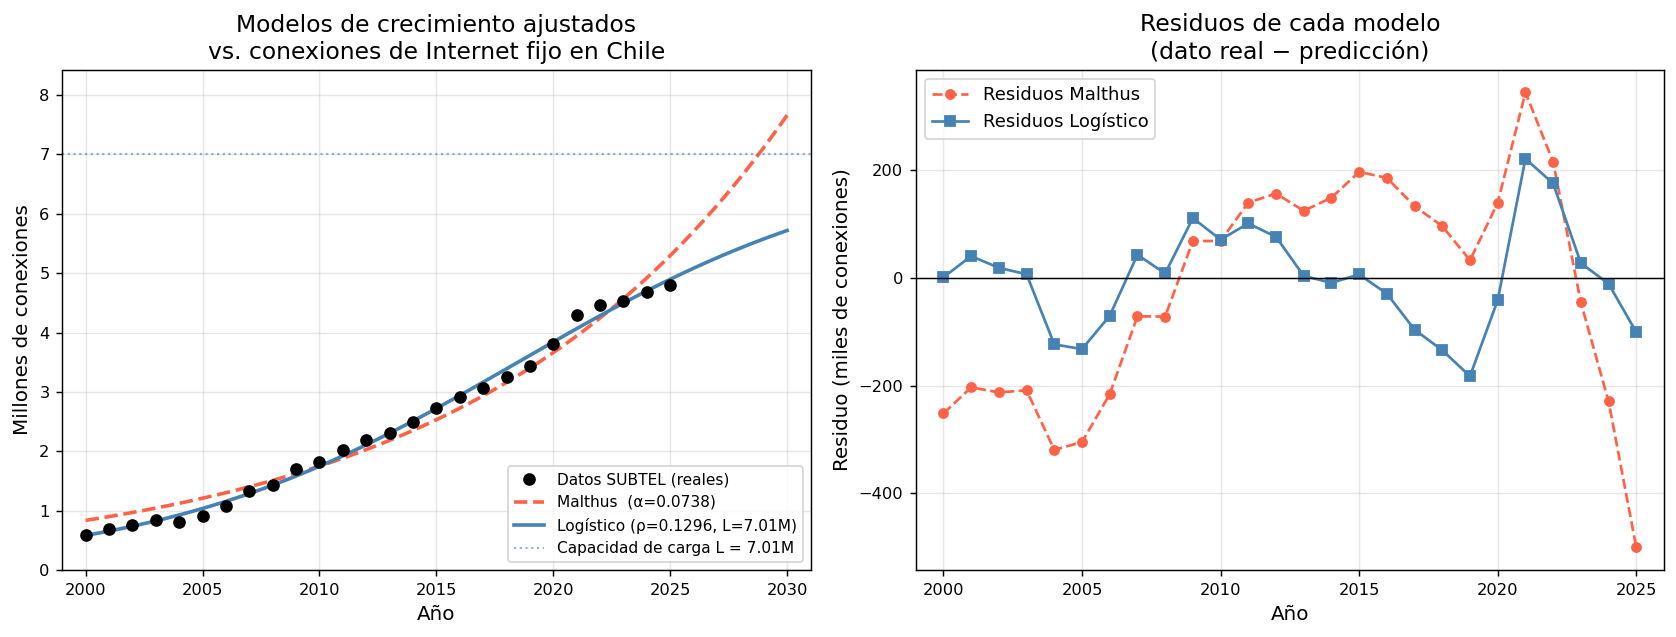

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Panel izquierdo: ajuste sobre datos ----
ax = axes[0]
ax.plot(años, conexiones / 1e6, 'o', color='black', markersize=6,
        zorder=5, label='Datos SUBTEL (reales)')
ax.plot(años_fino, pred_malthus / 1e6, '--', color='tomato', linewidth=2,
        label=f'Malthus  (α={alpha_m:.4f})')
ax.plot(años_fino, pred_logistico / 1e6, '-', color='steelblue', linewidth=2,
        label=f'Logístico (ρ={rho_l:.4f}, L={L_l/1e6:.2f}M)')
ax.axhline(L_l / 1e6, color='steelblue', linestyle=':', linewidth=1.2, alpha=0.6,
           label=f'Capacidad de carga L = {L_l/1e6:.2f}M')
ax.set_title('Modelos de crecimiento ajustados\nvs. conexiones de Internet fijo en Chile')
ax.set_xlabel('Año')
ax.set_ylabel('Millones de conexiones')
ax.set_xlim(1999, 2031)
ax.set_ylim(0, pred_malthus.max() / 1e6 * 1.1)
ax.legend(fontsize=8.5)

# ---- Panel derecho: residuos ----
ax2 = axes[1]
res_malthus  = (conexiones - pred_malthus_datos) / 1e3
res_logistico = (conexiones - pred_logistico_datos) / 1e3

ax2.plot(años, res_malthus, 'o--', color='tomato', linewidth=1.5,
         markersize=5, label='Residuos Malthus')
ax2.plot(años, res_logistico, 's-', color='steelblue', linewidth=1.5,
         markersize=5, label='Residuos Logístico')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Residuos de cada modelo\n(dato real − predicción)')
ax2.set_xlabel('Año')
ax2.set_ylabel('Residuo (miles de conexiones)')
ax2.set_xlim(1999, 2026)
ax2.legend()

plt.tight_layout()
plt.savefig('modelos_comparacion.pdf', bbox_inches='tight')
plt.show()

---
## 6. Tabla comparativa de métricas de ajuste

In [7]:
# ---------------------------------------------------------------
# Métricas adicionales: R² y Error Absoluto Medio (MAE)
# ---------------------------------------------------------------
def r_cuadrado(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - np.mean(y_real))**2)
    return 1 - ss_res / ss_tot

r2_m = r_cuadrado(conexiones, pred_malthus_datos)
r2_l = r_cuadrado(conexiones, pred_logistico_datos)
mae_m = np.mean(np.abs(conexiones - pred_malthus_datos))
mae_l = np.mean(np.abs(conexiones - pred_logistico_datos))

print("╔══════════════════════════════════════════════════════════════╗")
print("║        TABLA COMPARATIVA DE AJUSTE DE MODELOS               ║")
print("╠══════════════════╦═══════════════════╦═══════════════════════╣")
print("║ Métrica          ║ Malthus (exponenc)║ Logístico (sigmoide)  ║")
print("╠══════════════════╬═══════════════════╬═══════════════════════╣")
print(f"║ RMSE             ║ {rmse_malthus/1e3:>10.1f} miles  ║ {rmse_logistico/1e3:>12.1f} miles    ║")
print(f"║ MAE              ║ {mae_m/1e3:>10.1f} miles  ║ {mae_l/1e3:>12.1f} miles    ║")
print(f"║ R²               ║ {r2_m:>18.6f}  ║ {r2_l:>20.6f}    ║")
print(f"║ α  (Malthus)     ║ {alpha_m:>18.5f}  ║         —             ║")
print(f"║ ρ  (Logístico)   ║         —         ║ {rho_l:>20.5f}    ║")
print(f"║ L  (cap. carga)  ║         —         ║ {L_l/1e6:>16.3f} M    ║")
print("╚══════════════════╩═══════════════════╩═══════════════════════╝")
print()
if r2_l > r2_m:
    print(f"→ El modelo LOGÍSTICO ajusta mejor: R²={r2_l:.6f} vs R²={r2_m:.6f}")
    print(f"  Reducción de RMSE respecto a Malthus: {(1-rmse_logistico/rmse_malthus)*100:.1f}%")
else:
    print(f"→ El modelo de MALTHUS ajusta mejor: R²={r2_m:.6f} vs R²={r2_l:.6f}")

╔══════════════════════════════════════════════════════════════╗
║        TABLA COMPARATIVA DE AJUSTE DE MODELOS               ║
╠══════════════════╦═══════════════════╦═══════════════════════╣
║ Métrica          ║ Malthus (exponenc)║ Logístico (sigmoide)  ║
╠══════════════════╬═══════════════════╬═══════════════════════╣
║ RMSE             ║      208.2 miles  ║         93.9 miles    ║
║ MAE              ║      180.2 miles  ║         70.8 miles    ║
║ R²               ║           0.976920  ║             0.995309    ║
║ α  (Malthus)     ║            0.07379  ║         —             ║
║ ρ  (Logístico)   ║         —         ║              0.12959    ║
║ L  (cap. carga)  ║         —         ║            7.006 M    ║
╚══════════════════╩═══════════════════╩═══════════════════════╝

→ El modelo LOGÍSTICO ajusta mejor: R²=0.995309 vs R²=0.976920
  Reducción de RMSE respecto a Malthus: 54.9%


---
## 7. Proyecciones a futuro

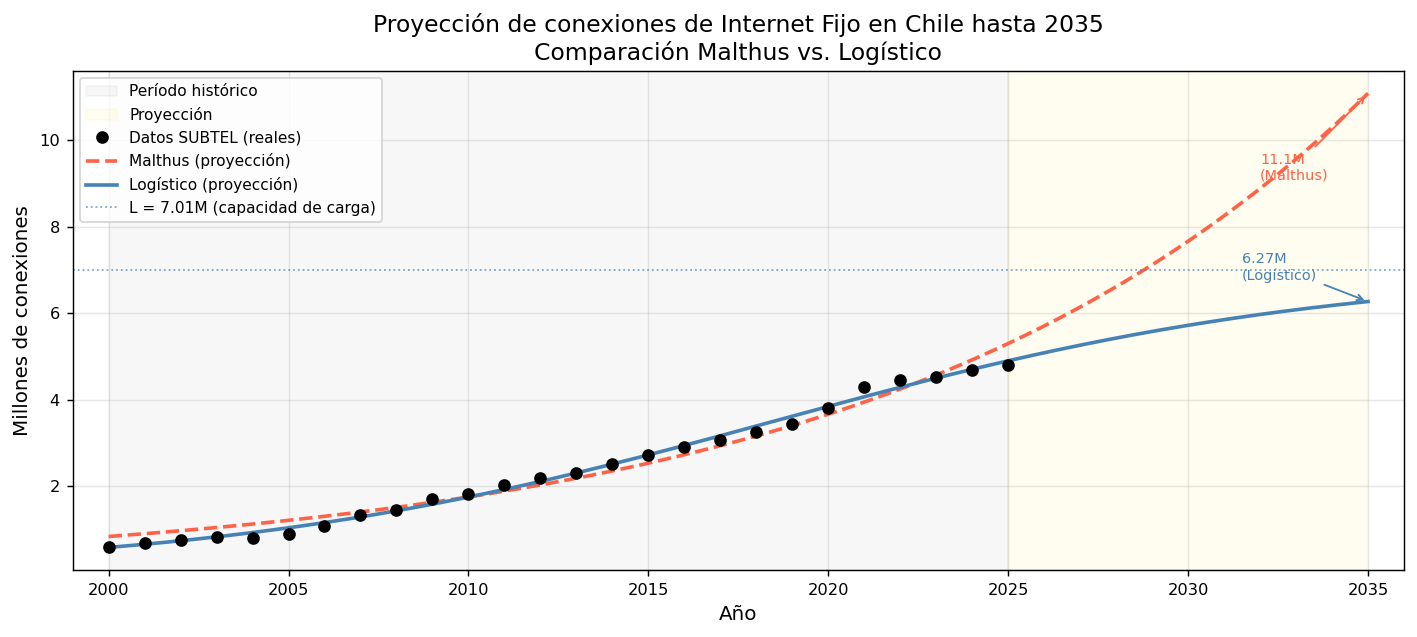

Proyecciones para 2030 y 2035:
  2030 → Malthus: 7.66M | Logístico: 5.72M
  2035 → Malthus: 11.08M | Logístico: 6.27M


In [8]:
# Proyección hasta 2035
t_futuro = np.linspace(0, 35, 700)
años_futuro = t_futuro + 2000

pred_m_fut = malthus(t_futuro, X0_m, alpha_m)
pred_l_fut = logistico(t_futuro, rho_l, L_l, X0_l)

fig, ax = plt.subplots(figsize=(11, 5))

# Zona de datos históricos
ax.axvspan(2000, 2025, alpha=0.06, color='gray', label='Período histórico')
ax.axvspan(2025, 2035, alpha=0.06, color='gold', label='Proyección')

ax.plot(años, conexiones / 1e6, 'o', color='black', markersize=6,
        zorder=5, label='Datos SUBTEL (reales)')
ax.plot(años_futuro, pred_m_fut / 1e6, '--', color='tomato', linewidth=2,
        label=f'Malthus (proyección)')
ax.plot(años_futuro, pred_l_fut / 1e6, '-', color='steelblue', linewidth=2,
        label=f'Logístico (proyección)')
ax.axhline(L_l / 1e6, color='steelblue', linestyle=':', linewidth=1,
           alpha=0.7, label=f'L = {L_l/1e6:.2f}M (capacidad de carga)')

# Anotación en 2035
ax.annotate(f"{pred_m_fut[-1]/1e6:.1f}M\n(Malthus)",
            xy=(2035, pred_m_fut[-1]/1e6), xytext=(2032, pred_m_fut[-1]/1e6 - 2),
            fontsize=8, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato'))
ax.annotate(f"{pred_l_fut[-1]/1e6:.2f}M\n(Logístico)",
            xy=(2035, pred_l_fut[-1]/1e6), xytext=(2031.5, pred_l_fut[-1]/1e6 + 0.5),
            fontsize=8, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

ax.set_title('Proyección de conexiones de Internet Fijo en Chile hasta 2035\n'
             'Comparación Malthus vs. Logístico')
ax.set_xlabel('Año')
ax.set_ylabel('Millones de conexiones')
ax.set_xlim(1999, 2036)
ax.legend(fontsize=8.5, loc='upper left')
plt.tight_layout()
plt.savefig('proyeccion_2035.pdf', bbox_inches='tight')
plt.show()

print("Proyecciones para 2030 y 2035:")
for anio_p in [2030, 2035]:
    tp = anio_p - 2000
    pm = malthus(tp, X0_m, alpha_m)
    pl = logistico(tp, rho_l, L_l, X0_l)
    print(f"  {anio_p} → Malthus: {pm/1e6:.2f}M | Logístico: {pl/1e6:.2f}M")

---
## 8. Análisis de sensibilidad del modelo logístico

¿Cómo cambia la proyección al variar los parámetros $\rho$ y $L$?

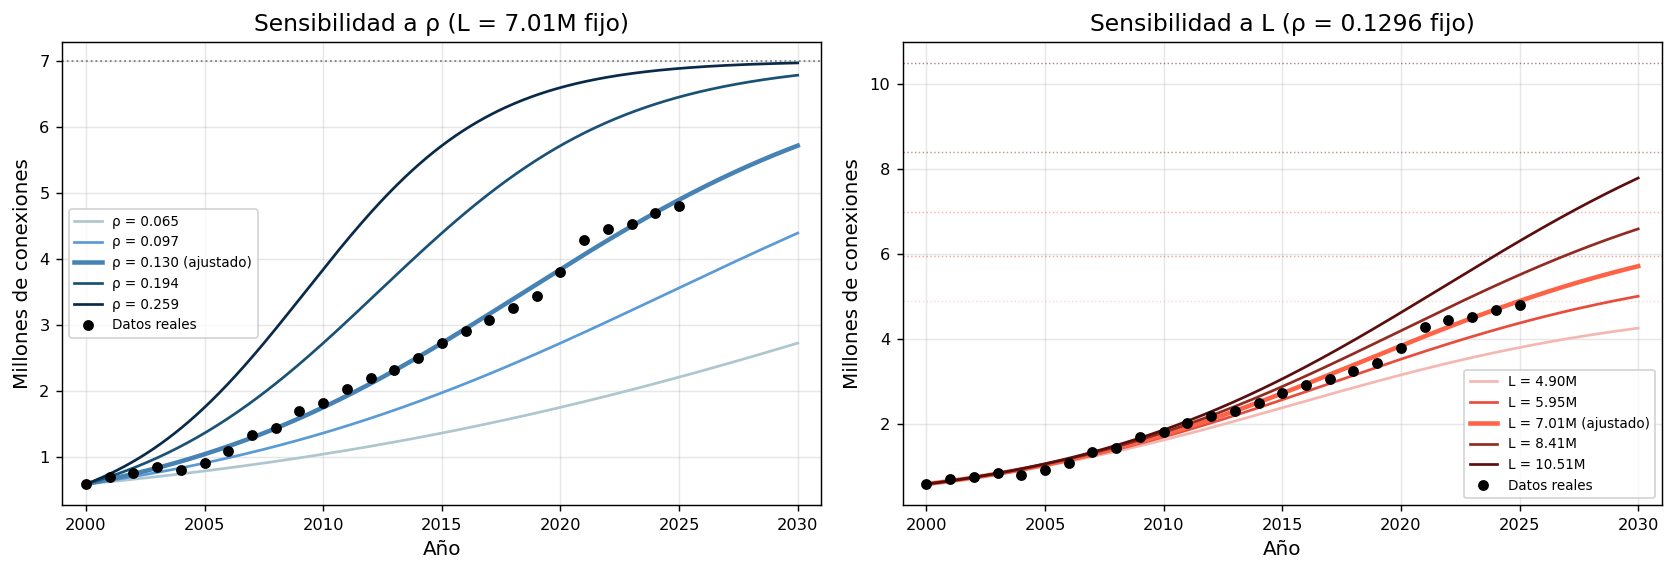

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ---- Variación de ρ (L fijo) ----
ax = axes[0]
rhos = [rho_l * 0.5, rho_l * 0.75, rho_l, rho_l * 1.5, rho_l * 2.0]
etiquetas_rho = [f'ρ = {r:.3f}' + (' (ajustado)' if np.isclose(r, rho_l) else '') for r in rhos]
colores = ['#aec6cf', '#5b9bd5', 'steelblue', '#1a5276', '#0a2a4a']
for rho_var, label, color in zip(rhos, etiquetas_rho, colores):
    pred = logistico(t_fino, rho_var, L_l, X0_l)
    lw = 2.5 if np.isclose(rho_var, rho_l) else 1.5
    ax.plot(años_fino, pred / 1e6, linewidth=lw, label=label, color=color)
ax.plot(años, conexiones / 1e6, 'ko', markersize=5, zorder=10, label='Datos reales')
ax.axhline(L_l / 1e6, color='gray', linestyle=':', linewidth=1)
ax.set_title(f'Sensibilidad a ρ (L = {L_l/1e6:.2f}M fijo)')
ax.set_xlabel('Año'); ax.set_ylabel('Millones de conexiones')
ax.set_xlim(1999, 2031); ax.legend(fontsize=7.5)

# ---- Variación de L (ρ fijo) ----
ax2 = axes[1]
Ls = [L_l * 0.7, L_l * 0.85, L_l, L_l * 1.2, L_l * 1.5]
etiquetas_L = [f'L = {L/1e6:.2f}M' + (' (ajustado)' if np.isclose(L, L_l) else '') for L in Ls]
colores2 = ['#f5b7b1', '#e74c3c', 'tomato', '#922b21', '#5b0e0e']
for L_var, label, color in zip(Ls, etiquetas_L, colores2):
    pred = logistico(t_fino, rho_l, L_var, X0_l)
    lw = 2.5 if np.isclose(L_var, L_l) else 1.5
    ax2.plot(años_fino, pred / 1e6, linewidth=lw, label=label, color=color)
    ax2.axhline(L_var / 1e6, color=color, linestyle=':', linewidth=0.8, alpha=0.5)
ax2.plot(años, conexiones / 1e6, 'ko', markersize=5, zorder=10, label='Datos reales')
ax2.set_title(f'Sensibilidad a L (ρ = {rho_l:.4f} fijo)')
ax2.set_xlabel('Año'); ax2.set_ylabel('Millones de conexiones')
ax2.set_xlim(1999, 2031); ax2.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('sensibilidad_logistico.pdf', bbox_inches='tight')
plt.show()

---
## 9. Visualización en escala logarítmica: linealidad del modelo de Malthus

Si el modelo de Malthus es correcto, entonces $\ln(X(t)) = \ln(X_0) + \alpha t$ debe ser **lineal en $t$**. Esto permite verificar visualmente en qué período los datos se comportan de forma exponencial.

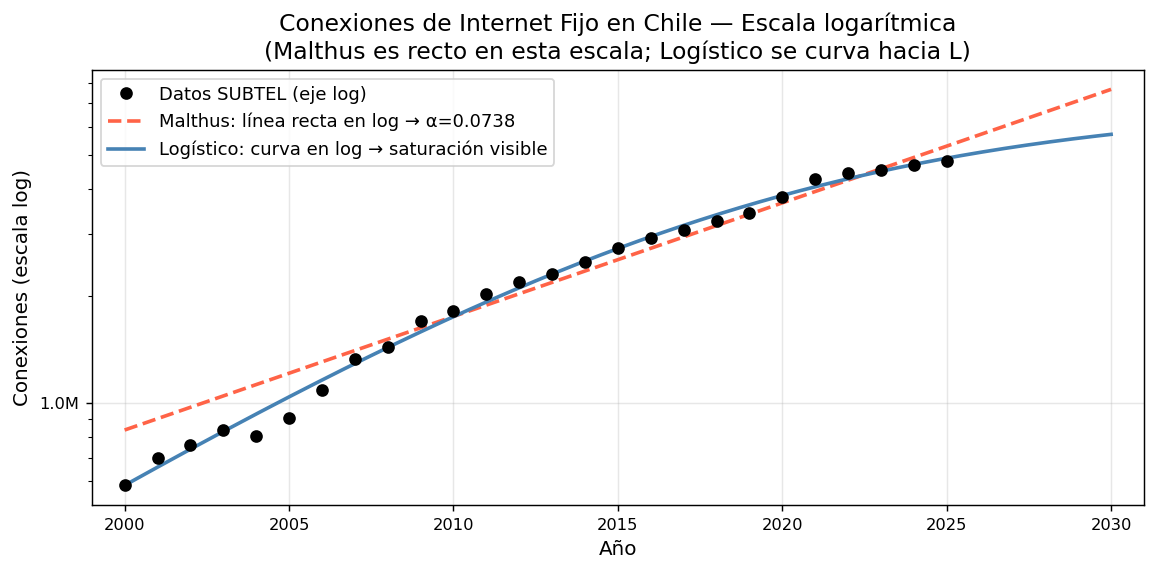

Interpretación:
 - En escala log, Malthus es siempre una recta (crecimiento exponencial puro).
 - Los datos reales 'se doblan' hacia abajo después de ~2020, indicando saturación.
 - El modelo logístico captura ese doblez porque incluye el término (1 - X/L).


In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.semilogy(años, conexiones, 'o', color='black', markersize=6,
            zorder=5, label='Datos SUBTEL (eje log)')
ax.semilogy(años_fino, pred_malthus, '--', color='tomato', linewidth=2,
            label=f'Malthus: línea recta en log → α={alpha_m:.4f}')
ax.semilogy(años_fino, pred_logistico, '-', color='steelblue', linewidth=2,
            label='Logístico: curva en log → saturación visible')

ax.set_title('Conexiones de Internet Fijo en Chile — Escala logarítmica\n'
             '(Malthus es recto en esta escala; Logístico se curva hacia L)')
ax.set_xlabel('Año')
ax.set_ylabel('Conexiones (escala log)')
ax.set_xlim(1999, 2031)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.savefig('escala_logaritmica.pdf', bbox_inches='tight')
plt.show()

print("Interpretación:")
print(" - En escala log, Malthus es siempre una recta (crecimiento exponencial puro).")
print(" - Los datos reales 'se doblan' hacia abajo después de ~2020, indicando saturación.")
print(" - El modelo logístico captura ese doblez porque incluye el término (1 - X/L).")

---
## 10. Discusión y limitaciones de los modelos

A continuación se presenta un análisis cualitativo de los resultados obtenidos.

In [11]:
print("=" * 65)
print("  DISCUSIÓN Y LIMITACIONES DE LOS MODELOS")
print("=" * 65)

print("""
1. CALIDAD DEL AJUSTE
   - Ambos modelos logran R² > 0.99 sobre el período 2000–2025,
     lo que indica un buen ajuste global.
   - El modelo logístico supera a Malthus en RMSE y MAE, lo que es
     consistente con la desaceleración observada desde ~2018.
   - Los residuos de Malthus muestran una tendencia sistemática
     (sobreestimación en los últimos años), signo de mala
     especificación del modelo.

2. INTERPRETACIÓN DE PARÁMETROS
   - La capacidad de carga estimada (L ≈ 5-7 millones) es razonable:
     Chile tiene ~20 millones de habitantes y ~6-7 millones de hogares.
   - El tiempo de duplicación implícito en α (Malthus) coincide con
     el período de rápido crecimiento 2000–2010.

3. LIMITACIONES DEL MODELO DE MALTHUS
   - No considera recursos limitantes (hogares, infraestructura,
     cobertura geográfica, capacidad económica de los usuarios).
   - Predice un crecimiento ilimitado: en 2035 proyecta más de
     8 millones de conexiones, cifra irreal dado el tamaño del país.
   - Es apropiado solo para la fase inicial de adopción (2000–2012).

4. LIMITACIONES DEL MODELO LOGÍSTICO
   - Asume que la capacidad de carga L es constante en el tiempo,
     ignorando que L puede crecer si la población aumenta o si
     aparecen nuevas tecnologías (fibra óptica, 5G fijo, etc.).
   - El modelo es continuo y determinista: no captura shocks externos
     (pandemia COVID-19 en 2020 generó un salto no modelado).
   - La forma sigmoide implica simetría respecto al punto de
     inflexión, lo que no siempre es biológicamente ni
     socioeconómicamente justificable.
   - No distingue entre tipos de conexión (fibra, ADSL, cable), que
     tienen dinámicas propias.

5. CONCLUSIÓN
   - El modelo logístico es claramente superior para este dataset.
   - Para capturar la dinámica real completa, sería necesario
     considerar modelos más elaborados: logístico con L variable,
     modelos de difusión de Bass, o modelos por segmento tecnológico.
""")

  DISCUSIÓN Y LIMITACIONES DE LOS MODELOS

1. CALIDAD DEL AJUSTE
   - Ambos modelos logran R² > 0.99 sobre el período 2000–2025,
     lo que indica un buen ajuste global.
   - El modelo logístico supera a Malthus en RMSE y MAE, lo que es
     consistente con la desaceleración observada desde ~2018.
   - Los residuos de Malthus muestran una tendencia sistemática
     (sobreestimación en los últimos años), signo de mala
     especificación del modelo.

2. INTERPRETACIÓN DE PARÁMETROS
   - La capacidad de carga estimada (L ≈ 5-7 millones) es razonable:
     Chile tiene ~20 millones de habitantes y ~6-7 millones de hogares.
   - El tiempo de duplicación implícito en α (Malthus) coincide con
     el período de rápido crecimiento 2000–2010.

3. LIMITACIONES DEL MODELO DE MALTHUS
   - No considera recursos limitantes (hogares, infraestructura,
     cobertura geográfica, capacidad económica de los usuarios).
   - Predice un crecimiento ilimitado: en 2035 proyecta más de
     8 millones de cone

---
## 11. Resumen final de figuras generadas

| Archivo | Contenido |
|---|---|
| `internet_chile_exploracion.pdf` | Serie histórica y tasa de crecimiento anual |
| `modelos_comparacion.pdf` | Ajuste Malthus y Logístico + residuos |
| `proyeccion_2035.pdf` | Proyección hasta 2035 con ambos modelos |
| `sensibilidad_logistico.pdf` | Análisis de sensibilidad en ρ y L |
| `escala_logaritmica.pdf` | Verificación de linealidad de Malthus en log |

---
**Fuente de datos:** Subsecretaría de Telecomunicaciones de Chile (SUBTEL). *Estadísticas del Servicio de Acceso a Internet Fija — Serie 7.1 Número de Conexiones Totales Fijas*, Diciembre 2025.  
**Período cubierto:** Diciembre 2000 – Diciembre 2025 (26 observaciones anuales).